# Redes neuronales para series de tiempo

Este notebook pronostica el número mensual de denuncias del fuero común para una entidad federativa (o para el total nacional). En vez de asumir que una sola técnica es mejor para todos los estados, compara cuatro modelos con **backtesting temporal** y selecciona, para cada serie, el de menor MAPE.

## Objetivo y enfoque

1. Cargar el archivo de delitos mensuales en formato Excel.
2. Transformar sus columnas de meses a una serie temporal mensual.
3. Evaluar cuatro métodos usando únicamente información disponible antes de cada mes evaluado.
4. Elegir el modelo con el menor error porcentual medio absoluto (MAPE).
5. Generar un pronóstico recursivo y una gráfica para la entidad elegida.

> **Importante:** el archivo de datos no se incluye en este notebook. Actualiza `RUTA` en la siguiente celda con la ubicación de tu archivo `.xlsx`.

## Marco legal y uso responsable de los datos

> **Nota informativa, no asesoría jurídica.** Esta sección resume el marco aplicable en México al **5 de agosto de 2026**. Si el análisis se va a publicar, utilizar en una institución o combinar con otras fuentes, debe revisarse con el área jurídica y de protección de datos correspondiente.

### Naturaleza de la información

La base utilizada contiene cifras agregadas de incidencia delictiva por entidad, tipo de delito y mes; el SESNSP publica esta información y sus diccionarios en formato de datos abiertos. El archivo describe registros estadísticos de denuncias o carpetas, **no identifica a víctimas, personas imputadas ni eventos individuales**. Por eso es adecuado para análisis agregado, series de tiempo, visualizaciones estatales y fines académicos o de política pública, siempre que se conserve su contexto metodológico y su fuente.

### Marco jurídico principal

1. **Ley General del Sistema Nacional de Seguridad Pública (LGSNSP).** Reconoce el Registro Nacional de Incidencia Delictiva dentro del Sistema Nacional de Información. El suministro de información debe observar objetividad, protección de datos personales y uso legítimo. [Texto vigente de la LGSNSP](https://www.diputados.gob.mx/LeyesBiblio/pdf/LGSNSP.pdf).
2. **Ley General de Transparencia y Acceso a la Información Pública.** Sustenta el acceso a información pública y su reutilización, atendiendo las clasificaciones y restricciones legales que correspondan. [Consulta legislativa oficial](https://www.diputados.gob.mx/LeyesBiblio/index1.htm).
3. **Ley General de Protección de Datos Personales en Posesión de Sujetos Obligados.** Protege los datos de personas identificadas o identificables en manos de autoridades y exige observar, entre otros, los principios de licitud, finalidad, proporcionalidad, calidad y responsabilidad cuando exista tratamiento de datos personales. [Texto vigente de la LGPDPPSO](https://www.diputados.gob.mx/LeyesBiblio/pdf/LGPDPPSO.pdf).

### Reglas prácticas para este notebook

- **Sí se puede:** analizar tendencias agregadas, comparar entidades, construir mapas estatales, estimar pronósticos y citar la fuente y fecha de descarga.
- **No se debe inferir:** que una persona concreta cometió un delito, que una víctima vivió un evento específico, ni que un estado es “más peligroso” únicamente por el volumen absoluto. Para comparaciones territoriales, use tasas por población además de conteos.
- **No reidentificar ni cruzar indebidamente:** no combine estas cifras con fuentes que permitan identificar personas, domicilios o casos individuales sin una base jurídica, finalidad definida y salvaguardas aplicables.
- **Comunicar límites:** los datos pueden tener subregistro, reclasificaciones y actualizaciones retroactivas; el SESNSP señala que los datos abiertos incluyen diccionarios y metodologías. Un pronóstico es una estimación estadística, no una certeza ni una base suficiente para decisiones individuales, sanciones o acciones policiales.
- **Trazabilidad:** al compartir resultados, indique el origen (SESNSP), fecha de descarga, período, variables agregadas, transformaciones y versión/metodología empleada. La fuente oficial puede consultarse en [Datos abiertos de incidencia delictiva del SESNSP](https://www.gob.mx/sesnsp/acciones-y-programas/datos-abiertos-de-incidencia-delictiva).

In [ ]:
# Si hace falta, instala dependencias desde una terminal:
# pip install pandas numpy matplotlib scikit-learn openpyxl

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# --- Parámetros editables ---
RUTA = r"datos\Estatal-Delitos-2015-2025_dic2025.xlsx"  # CAMBIAR
ENTIDAD_FILTRO = "Sonora"   # nombre exacto del estado; usa None para Nacional
CORRER_TODOS = True          # compara los modelos para todas las entidades
N_TEST = 6                   # últimos meses usados para backtesting
W = 12                       # tamaño de ventana: un ciclo anual
REPS = 10                    # redes del ensamble; subirlo aumenta el tiempo de cómputo
H = 6                        # horizonte del pronóstico, en meses

## 1. Preparación de los datos

La fuente viene en formato **ancho**: cada fila contiene columnas `Enero` a `Diciembre`. Para analizar una serie temporal, se convierte a formato **largo**, dejando una fila por combinación de registro y mes. Después se construye `Fecha` como el primer día de cada mes.

`construir_serie` suma todos los delitos de la entidad en cada fecha. Al pasar `None`, no filtra por entidad y por tanto devuelve el agregado nacional. `asfreq("MS")` fija una frecuencia mensual al inicio de mes; si faltara un mes en la fuente aparecería como dato faltante y convendría investigarlo antes de entrenar.

In [ ]:
delitos_raw = pd.read_excel(RUTA)

MESES = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre",
]
MESES_NUM = {mes: numero for numero, mes in enumerate(MESES, start=1)}

columnas_id = [
    "Año", "Clave_Ent", "Entidad", "Bien jurídico afectado",
    "Tipo de delito", "Subtipo de delito", "Modalidad",
]

delitos = delitos_raw.melt(
    id_vars=columnas_id,
    value_vars=MESES,
    var_name="Mes",
    value_name="Denuncias",
)
delitos["Fecha"] = pd.to_datetime(
    delitos["Año"].astype(str) + "-" +
    delitos["Mes"].map(MESES_NUM).astype(str) + "-01"
)

ESTADOS = sorted(delitos["Entidad"].dropna().unique())

def construir_serie(entidad):
    """Devuelve una serie mensual de denuncias para un estado o para el total nacional."""
    sub = delitos if entidad is None else delitos[delitos["Entidad"] == entidad]
    return sub.groupby("Fecha")["Denuncias"].sum().asfreq("MS").sort_index()

print(f"Entidades detectadas: {len(ESTADOS)}")
display(delitos[["Entidad", "Fecha", "Denuncias"]].head())

## 2. Modelos candidatos

Todos los modelos reciben solamente el historial `tr` y predicen el mes siguiente. Esa interfaz común es crucial: permite compararlos sin filtrar información futura.

- **NN_actual:** red multicapa con 12 observaciones previas como entrada; predice el nivel del mes siguiente y usa escalamiento Min-Max.
- **NN_mejorado:** predice el cambio frente al mismo mes del año anterior. Al separar la estacionalidad anual, la red tiene una tarea más simple; después se suma el cambio a `tr[-12]` para recuperar el nivel.
- **S-Naive:** usa el valor del mismo mes del año previo. Es un punto de comparación muy fuerte cuando hay estacionalidad estable.
- **S-Naive+tend:** parte del valor estacional y ajusta la mitad de la tendencia interanual reciente.

Las redes se entrenan varias veces con semillas distintas y se promedian sus predicciones. El ensamble reduce la variación derivada de la inicialización aleatoria.

In [ ]:
def m_nn_actual(tr, W=W, reps=REPS):
    """Red (100, 50), tanh: 12 rezagos -> nivel del próximo mes."""
    Xr, yr = [], []
    for i in range(W, len(tr)):
        Xr.append(tr[i - W:i])
        yr.append(tr[i])
    X, y = np.array(Xr), np.array(yr)

    sx, sy = MinMaxScaler(), MinMaxScaler()
    Xs = sx.fit_transform(X)
    ys = sy.fit_transform(y.reshape(-1, 1)).ravel()
    ultima_ventana = sx.transform(tr[-W:].reshape(1, -1))

    preds = []
    for semilla in range(reps):
        red = MLPRegressor(
            hidden_layer_sizes=(100, 50), activation="tanh", max_iter=2000,
            random_state=semilla, early_stopping=True, n_iter_no_change=20,
            validation_fraction=0.1,
        )
        red.fit(Xs, ys)
        pred_esc = red.predict(ultima_ventana).reshape(-1, 1)
        preds.append(sy.inverse_transform(pred_esc)[0, 0])
    return np.mean(preds)


def m_nn_mejorado(tr, W=W, reps=REPS):
    """Red (32,) que predice el cambio interanual y reconstruye el nivel."""
    Xr, yr = [], []
    for i in range(W, len(tr)):
        Xr.append(tr[i - W:i])
        yr.append(tr[i] - tr[i - 12])
    X, y = np.array(Xr), np.array(yr)

    sx, sy = StandardScaler(), StandardScaler()
    Xs = sx.fit_transform(X)
    ys = sy.fit_transform(y.reshape(-1, 1)).ravel()
    ultima_ventana = sx.transform(tr[-W:].reshape(1, -1))

    preds = []
    for semilla in range(reps):
        red = MLPRegressor(
            hidden_layer_sizes=(32,), activation="relu", alpha=0.01,
            max_iter=3000, random_state=semilla, early_stopping=True,
            n_iter_no_change=30, validation_fraction=0.15,
        )
        red.fit(Xs, ys)
        cambio = sy.inverse_transform(red.predict(ultima_ventana).reshape(-1, 1))[0, 0]
        preds.append(tr[-12] + cambio)
    return np.mean(preds)


def m_snaive(tr, W=W):
    """Pronóstico estacional ingenuo: repite el valor de hace 12 meses."""
    return tr[-12]


def m_snaive_tend(tr, W=W):
    """Estacional ingenuo con ajuste parcial por tendencia interanual reciente."""
    base = tr[-12]
    tendencia = np.mean(tr[-3:]) - np.mean(tr[-15:-12])
    return base + 0.5 * tendencia


MODELOS = {
    "NN_actual": m_nn_actual,
    "NN_mejorado": m_nn_mejorado,
    "S-Naive": m_snaive,
    "S-Naive+tend": m_snaive_tend,
}

## 3. Backtesting temporal y selección

El backtesting simula el uso real del modelo. Para cada uno de los últimos `N_TEST` meses, se corta la serie justo antes de ese mes, se ajusta el modelo con el pasado y se genera una predicción de un paso. Nunca se entrena con valores posteriores al mes evaluado.

La métrica principal es **MAPE**: el promedio del error absoluto dividido por el valor real, expresado como porcentaje. Es fácil de interpretar, aunque puede ser inestable si los valores reales son cero o muy pequeños. También se reporta **MAE**, el error absoluto medio en número de denuncias.

In [ ]:
def backtest(serie_vals, fn, n_test=N_TEST, W=W):
    """Evalúa predicciones de un paso para los últimos n_test meses."""
    if len(serie_vals) < W + n_test + 1:
        raise ValueError("La serie no tiene suficientes meses para entrenar y hacer backtesting.")
    if np.any(serie_vals[-n_test:] == 0):
        raise ValueError("No se puede calcular MAPE si hay valores reales iguales a cero.")

    reales = serie_vals[-n_test:]
    predicciones = np.array([
        fn(serie_vals[:len(serie_vals) - n_test + k], W)
        for k in range(n_test)
    ])
    mape = np.mean(np.abs((reales - predicciones) / reales)) * 100
    mae = mean_absolute_error(reales, predicciones)
    return mape, mae, predicciones, reales


def elegir_mejor_modelo(serie_vals):
    """Devuelve el nombre del menor MAPE y el diccionario completo de MAPEs."""
    mapes = {nombre: backtest(serie_vals, funcion)[0] for nombre, funcion in MODELOS.items()}
    return min(mapes, key=mapes.get), mapes


def pronosticar_futuro(serie_vals, fn, h=H, W=W):
    """Genera h pronósticos recursivos; cada predicción se incorpora al historial."""
    historial = serie_vals.copy()
    futuro = []
    for _ in range(h):
        pred = fn(historial, W)
        futuro.append(pred)
        historial = np.append(historial, pred)
    return np.array(futuro)

## 4. Comparación opcional de las entidades

Al activar `CORRER_TODOS`, se evalúan los cuatro modelos para cada entidad y se crea `ranking_modelos_por_estado.csv`. Este proceso puede tardar, ya que cada evaluación de una red implica reentrenarla para cada mes de backtesting y cada repetición del ensamble.

El modelo ganador se elige **por estado**, no por el promedio nacional. Esto reconoce que algunas series son más estables y otras presentan cambios que una red puede captar mejor.

In [ ]:
if CORRER_TODOS:
    filas = []
    print("BARRIDO DE ENTIDADES: backtesting y selección del menor MAPE")
    for entidad in ESTADOS:
        valores = construir_serie(entidad).values.astype(float)
        mejor, mapes = elegir_mejor_modelo(valores)
        filas.append({
            "Estado": entidad,
            **{nombre: round(valor, 1) for nombre, valor in mapes.items()},
            "Mejor modelo": mejor,
            "MAPE mejor": round(mapes[mejor], 1),
        })
        print(f"{entidad:<32} {mejor:<13} ({mapes[mejor]:.1f}%)")

    tabla = pd.DataFrame(filas).sort_values("MAPE mejor")
    display(tabla)
    print("\nPromedio de MAPE:")
    display(tabla[["NN_actual", "NN_mejorado", "S-Naive", "S-Naive+tend", "MAPE mejor"]].mean().to_frame("MAPE (%)"))
    print("\nNúmero de victorias por modelo:")
    display(tabla["Mejor modelo"].value_counts().to_frame("Estados"))
    tabla.to_csv("ranking_modelos_por_estado.csv", index=False, encoding="utf-8-sig")

## 5. Diagnóstico y pronóstico de la entidad seleccionada

Esta sección selecciona el modelo de menor MAPE para `ENTIDAD_FILTRO`, muestra el desempeño de cada alternativa y produce `H` meses futuros. El pronóstico es **recursivo**: al estimar más de un mes, los valores proyectados sustituyen a los datos que aún no existen. Por ello, la incertidumbre normalmente aumenta con el horizonte.

In [6]:
serie = construir_serie(ENTIDAD_FILTRO)
if serie.isna().any():
    raise ValueError("La serie contiene meses faltantes. Revise el archivo antes de pronosticar.")

serie_vals = serie.values.astype(float)
etiqueta = ENTIDAD_FILTRO if ENTIDAD_FILTRO is not None else "Nacional"

mejor, mapes = elegir_mejor_modelo(serie_vals)
fn_mejor = MODELOS[mejor]
mape_bt, mae_bt, preds_bt, reales_bt = backtest(serie_vals, fn_mejor)

print(f"Entidad: {etiqueta}")
print("MAPE por modelo:")
for nombre, valor in sorted(mapes.items(), key=lambda par: par[1]):
    elegido = "  ← ELEGIDO" if nombre == mejor else ""
    print(f"  {nombre:<14}: {valor:5.1f}%{elegido}")
print(f"\nMAE del modelo elegido: {mae_bt:,.0f} denuncias por mes")

futuro = pronosticar_futuro(serie_vals, fn_mejor, h=H)
fechas_fut = pd.date_range(serie.index[-1] + pd.DateOffset(months=1), periods=H, freq="MS")
pronostico = pd.DataFrame({"Fecha": fechas_fut, "Pronóstico": futuro.round()})
display(pronostico)

Entidad: Sonora
MAPE por modelo:
  NN_actual     :  13.3%  ← ELEGIDO
  NN_mejorado   :  20.4%
  S-Naive+tend  :  20.4%
  S-Naive       :  24.7%

MAE del modelo elegido: 336 denuncias por mes


,Fecha,Pronóstico
0,2026-01-01,2361.0
1,2026-02-01,2424.0
2,2026-03-01,2480.0
3,2026-04-01,2543.0
4,2026-05-01,2578.0
5,2026-06-01,2564.0


## 6. Mapa de concentración de denuncias por entidad

Este mapa coroplético permite identificar las zonas con mayor concentración de denuncias. Para cada entidad calcula su participación porcentual respecto al total nacional del período elegido; por ejemplo, un valor de 12 % significa que 12 de cada 100 denuncias registradas en el período ocurrieron allí. Los tonos más oscuros representan porcentajes mayores.

Por defecto se usa todo el período disponible. Cambia `PERIODO_MAPA` a `"ultimo_mes"` para visualizar únicamente el mes más reciente. Esta es una medida de **volumen**, no de tasa delictiva: los estados más poblados suelen concentrar más denuncias. Para comparar riesgo relativo habría que dividir por población y mostrar una tasa por cada 100 mil habitantes.

Advertencia: entidades sin datos después de unir: ['Veracruz', 'Michoacán', 'Coahuila']


,Entidad,Porcentaje_nacional,Denuncias_totales
16,México,18.06%,"3,924,507"
6,Ciudad de México,10.86%,"2,359,144"
13,Jalisco,6.77%,"1,471,946"
10,Guanajuato,6.71%,"1,458,047"
1,Baja California,5.38%,"1,168,206"


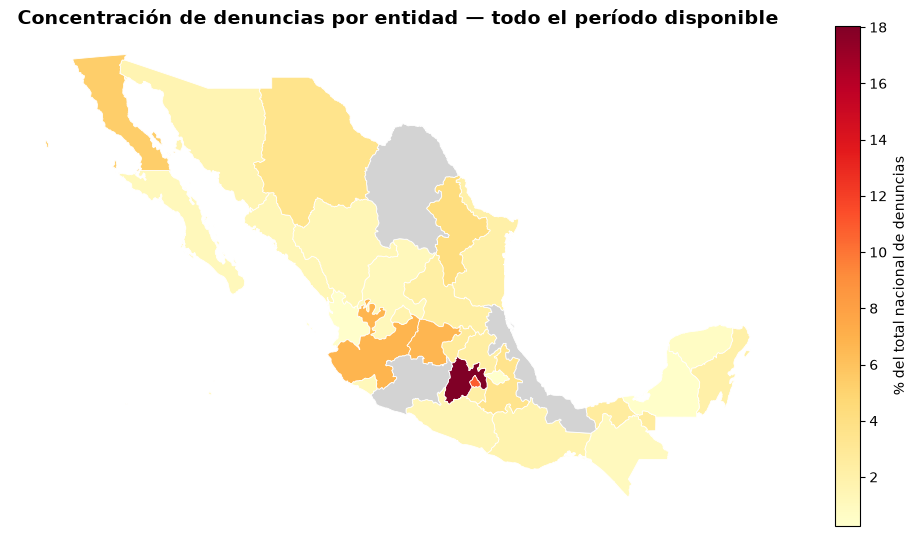

In [7]:
# Instala una sola vez si es necesario: pip install geopandas requests
import re
import unicodedata
import geopandas as gpd
import requests

PERIODO_MAPA = "todo"  # opciones: "todo" o "ultimo_mes"
URL_GEOJSON = "https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json"

def normalizar_nombre(texto):
    """Uniforma acentos, mayúsculas y espacios para unir fuentes con nombres distintos."""
    texto = unicodedata.normalize("NFD", str(texto))
    texto = "".join(c for c in texto if unicodedata.category(c) != "Mn")
    return re.sub(r"\\s+", " ", texto).strip().upper()

# Agregación: todo el histórico o únicamente el último mes disponible.
datos_mapa = delitos.copy()
if PERIODO_MAPA == "ultimo_mes":
    ultima_fecha = datos_mapa["Fecha"].max()
    datos_mapa = datos_mapa[datos_mapa["Fecha"] == ultima_fecha]
    titulo_periodo = f"{ultima_fecha.strftime('%B de %Y')}"
else:
    titulo_periodo = "todo el período disponible"

resumen_mapa = (datos_mapa.groupby("Entidad", as_index=False)["Denuncias"].sum()
                .rename(columns={"Denuncias": "Denuncias_totales"}))
resumen_mapa["Porcentaje_nacional"] = (
    100 * resumen_mapa["Denuncias_totales"] / resumen_mapa["Denuncias_totales"].sum()
)
resumen_mapa["clave_union"] = resumen_mapa["Entidad"].map(normalizar_nombre)

# Se descarga una geometría pública de los estados mexicanos para dibujar el mapa.
respuesta = requests.get(URL_GEOJSON, timeout=30)
respuesta.raise_for_status()
mapa_mexico = gpd.GeoDataFrame.from_features(respuesta.json()["features"], crs="EPSG:4326")
mapa_mexico["clave_union"] = mapa_mexico["name"].map(normalizar_nombre)

mapa_datos = mapa_mexico.merge(resumen_mapa, on="clave_union", how="left", validate="one_to_one")
sin_unir = mapa_datos[mapa_datos["Porcentaje_nacional"].isna()]["name"].tolist()
if sin_unir:
    print("Advertencia: entidades sin datos después de unir:", sin_unir)

top_5 = resumen_mapa.nlargest(5, "Porcentaje_nacional")[["Entidad", "Porcentaje_nacional", "Denuncias_totales"]]
display(top_5.style.format({"Porcentaje_nacional": "{:.2f}%", "Denuncias_totales": "{:,.0f}"}))

fig, ax = plt.subplots(figsize=(10, 8))
mapa_datos.plot(
    column="Porcentaje_nacional", cmap="YlOrRd", linewidth=0.6,
    edgecolor="white", legend=True,
    legend_kwds={"label": "% del total nacional de denuncias", "shrink": 0.65}, ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)
ax.set_title(f"Concentración de denuncias por entidad — {titulo_periodo}",
             fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Interpretación de la gráfica de pronóstico

- La línea azul es el historial observado.
- Los puntos dorados son las predicciones de backtesting; las líneas punteadas muestran su distancia respecto al valor real (marca azul).
- La línea roja representa el pronóstico futuro con el modelo seleccionado.
- La línea vertical separa la última observación real del período pronosticado.

Un MAPE bajo en seis meses es una señal favorable, pero no garantiza el desempeño futuro: cambios normativos, de registro o hechos extraordinarios pueden alterar la serie. Para decisiones importantes, conviene complementar este resultado con intervalos de predicción, validación en más ventanas temporales y conocimiento del contexto delictivo.

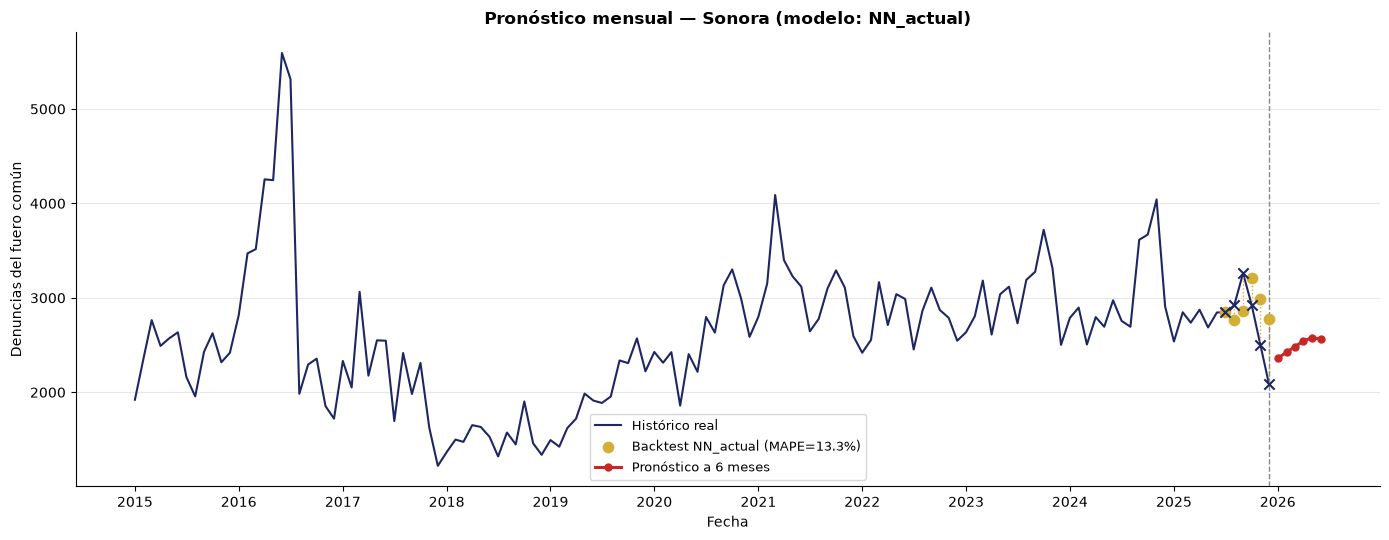

In [21]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(serie.index, serie.values, color="#1E2761", linewidth=1.5, label="Histórico real")

fechas_bt = serie.index[-N_TEST:]
ax.scatter(fechas_bt, preds_bt, color="#D4AF37", zorder=5, s=55,
           label=f"Backtest {mejor} (MAPE={mape_bt:.1f}%)")
ax.scatter(fechas_bt, reales_bt, color="#1E2761", zorder=5, s=55, marker="x")
for fecha, real, pred in zip(fechas_bt, reales_bt, preds_bt):
    ax.plot([fecha, fecha], [real, pred], color="#D4AF37", linewidth=1, linestyle=":")

ax.plot(fechas_fut, futuro, color="#C62828", linewidth=2.2, marker="o", markersize=5,
        label=f"Pronóstico a {H} meses")
ax.axvline(serie.index[-1], color="#888888", linewidth=1, linestyle="--")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Fecha")
ax.set_ylabel("Denuncias del fuero común")
ax.set_title(f"Pronóstico mensual — {etiqueta} (modelo: {mejor})", fontweight="bold")
ax.legend(fontsize=9.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 8. Generar reporte ejecutivo en PDF

Ejecuta esta celda al final para crear un documento listo para entregar, sin código. El PDF incluye: portada, resumen ejecutivo, tabla de seis pronósticos, gráfica histórica con pronóstico, mapa de concentración de denuncias y una nota de uso responsable.

El archivo se guarda en la carpeta `reportes` junto al notebook. Si hace falta, instala ReportLab una vez con `pip install reportlab`.

In [22]:
from pathlib import Path
from tempfile import TemporaryDirectory
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Image,
                                Table, TableStyle, PageBreak)

# Nombre y ubicación del entregable.
CARPETA_REPORTES = Path("reportes")
CARPETA_REPORTES.mkdir(exist_ok=True)
nombre_archivo = f"Reporte_ejecutivo_denuncias_{etiqueta.replace(' ', '_')}.pdf"
ruta_pdf = CARPETA_REPORTES / nombre_archivo

def encabezado_pie(canvas, doc):
    """Agrega pie de página institucional a cada hoja."""
    canvas.saveState()
    canvas.setFont("Helvetica", 8)
    canvas.setFillColor(colors.HexColor("#5A5A5A"))
    canvas.drawString(0.65 * inch, 0.4 * inch, "Fuente: SESNSP - datos abiertos de incidencia delictiva")
    canvas.drawRightString(7.85 * inch, 0.4 * inch, f"Pagina {doc.page}")
    canvas.restoreState()

with TemporaryDirectory() as directorio_temporal:
    tmp = Path(directorio_temporal)
    grafica_png = tmp / "pronostico.png"
    mapa_png = tmp / "mapa.png"

    # Figura 1: histórico y pronóstico.
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.plot(serie.index, serie.values, color="#1E2761", linewidth=1.5, label="Histórico")
    ax.scatter(fechas_bt, preds_bt, color="#D4AF37", s=35,
               label=f"Backtest (MAPE {mape_bt:.1f}%)")
    ax.plot(fechas_fut, futuro, color="#C62828", linewidth=2, marker="o",
            label="Pronóstico a 6 meses")
    ax.axvline(serie.index[-1], color="#777777", linewidth=0.8, linestyle="--")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_ylabel("Denuncias")
    ax.set_title(f"Histórico y pronóstico - {etiqueta}", fontweight="bold")
    ax.grid(alpha=0.25, axis="y")
    ax.legend(fontsize=8, ncol=3, loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(grafica_png, dpi=180, bbox_inches="tight")
    plt.close(fig)

    # Figura 2: mapa de concentración nacional calculado en la sección anterior.
    fig, ax = plt.subplots(figsize=(7, 5.5))
    mapa_datos.plot(column="Porcentaje_nacional", cmap="YlOrRd", linewidth=0.5,
                    edgecolor="white", legend=True,
                    legend_kwds={"label": "% del total nacional", "shrink": 0.65}, ax=ax)
    ax.set_title(f"Concentración de denuncias - {titulo_periodo}", fontweight="bold")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(mapa_png, dpi=180, bbox_inches="tight")
    plt.close(fig)

    estilos = getSampleStyleSheet()
    estilos.add(ParagraphStyle(name="TituloReporte", parent=estilos["Title"], alignment=TA_CENTER,
                                textColor=colors.HexColor("#1E2761"), fontSize=22, leading=27))
    estilos.add(ParagraphStyle(name="Subtitulo", parent=estilos["Heading2"], textColor=colors.HexColor("#1E2761"),
                                fontSize=14, spaceBefore=8, spaceAfter=6))
    estilos.add(ParagraphStyle(name="Texto", parent=estilos["BodyText"], fontSize=10, leading=14,
                                alignment=TA_LEFT, spaceAfter=6))

    historia = []
    historia += [Spacer(1, 0.65 * inch),
                 Paragraph("Reporte ejecutivo", estilos["TituloReporte"]),
                 Spacer(1, 0.15 * inch),
                 Paragraph(f"Pronóstico de denuncias mensuales - {etiqueta}", estilos["Heading1"]),
                 Spacer(1, 0.25 * inch),
                 Paragraph(f"Periodo histórico: {serie.index.min().strftime('%B de %Y')} a {serie.index.max().strftime('%B de %Y')}", estilos["Texto"]),
                 Paragraph(f"Fecha de elaboración: {pd.Timestamp.today().strftime('%d/%m/%Y')}", estilos["Texto"]),
                 Spacer(1, 2.1 * inch),
                 Paragraph("Documento de apoyo para planeación y análisis estadístico.", estilos["Texto"]),
                 Paragraph("No contiene información personal ni permite identificar personas o casos individuales.", estilos["Texto"]),
                 PageBreak()]

    historia += [Paragraph("Resumen ejecutivo", estilos["Subtitulo"]),
                 Paragraph(
                     f"Para {etiqueta}, el modelo seleccionado fue <b>{mejor}</b>, porque obtuvo el menor error en backtesting. "
                     f"Su MAPE fue de <b>{mape_bt:.1f}%</b> y su error absoluto medio fue de <b>{mae_bt:,.0f}</b> denuncias por mes.",
                     estilos["Texto"]),
                 Paragraph(
                     "El pronóstico cubre los siguientes seis meses. Es una estimación estadística basada en el comportamiento histórico; "
                     "debe interpretarse junto con el contexto operativo y no como una certeza.", estilos["Texto"]),
                 Spacer(1, 0.08 * inch), Image(str(grafica_png), width=7.0 * inch, height=2.8 * inch),
                 Spacer(1, 0.12 * inch),
                 Paragraph("Pronóstico de los próximos seis meses", estilos["Subtitulo"])]

    filas_tabla = [["Mes", "Denuncias estimadas"]]
    filas_tabla += [[fecha.strftime("%B %Y").capitalize(), f"{valor:,.0f}"]
                    for fecha, valor in zip(fechas_fut, futuro)]
    tabla_pdf = Table(filas_tabla, colWidths=[3.6 * inch, 2.1 * inch], hAlign="LEFT")
    tabla_pdf.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1E2761")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("ALIGN", (1, 1), (1, -1), "RIGHT"),
        ("GRID", (0, 0), (-1, -1), 0.3, colors.HexColor("#C9CED6")),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#F2F5F8")]),
        ("TOPPADDING", (0, 0), (-1, -1), 6), ("BOTTOMPADDING", (0, 0), (-1, -1), 6),
    ]))
    historia += [tabla_pdf, PageBreak(),
                 Paragraph("Contexto nacional", estilos["Subtitulo"]),
                 Paragraph(
                     "El mapa muestra la participación porcentual de cada entidad en el total de denuncias registradas. "
                     "Los tonos más oscuros indican una mayor concentración de volumen.", estilos["Texto"]),
                 Image(str(mapa_png), width=5.9 * inch, height=4.6 * inch),
                 Paragraph("Uso responsable y límites", estilos["Subtitulo"]),
                 Paragraph(
                     "Las cifras son agregadas y provienen de datos abiertos del SESNSP. Pueden existir subregistro, actualizaciones o cambios de clasificación. "
                     "El análisis no debe utilizarse para identificar personas, atribuir responsabilidad individual ni sustituir la evaluación profesional y operativa.",
                     estilos["Texto"])]

    documento = SimpleDocTemplate(str(ruta_pdf), pagesize=letter,
                                  rightMargin=0.65 * inch, leftMargin=0.65 * inch,
                                  topMargin=0.6 * inch, bottomMargin=0.65 * inch)
    documento.build(historia, onFirstPage=encabezado_pie, onLaterPages=encabezado_pie)

print(f"Reporte PDF generado correctamente: {ruta_pdf.resolve()}")

Reporte PDF generado correctamente: C:\Users\User\Desktop\RedesNproycF\reportes\Reporte_ejecutivo_denuncias_Sonora.pdf
